# Land Use Classification from Satellite Images  

Group 4: Teresa Alvarez, Vikram Bhatt, Alessandro Cristofolini, Matteo Khoueiri, Dominique Robson, & Pengchong Zhao

---

## Executive Summary

This project addresses land use classification from satellite image patches using the EuroSAT RGB dataset.

The goal is to classify each image into one of 10 land-use categories.

Two modelling approaches are compared:

1. A classical machine learning baseline based on HOG feature extraction and Random Forest classification.
2. A deep learning approach based on a Convolutional Neural Network (CNN).

This comparison allows us to evaluate the strengths and limitations of handcrafted features versus automatically learned image representations.


----
# 1. Research Question

## Problem

Can satellite image patches be automatically classified into land-use categories in a reliable way?

## Motivation

Manual annotation of satellite imagery is costly and time-consuming. Automated classification can support environmental monitoring, land-use analysis and urban planning.

The system is intended as a decision-support tool rather than as a fully autonomous solution.

In [1]:
from pathlib import Path
import random
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# 2. Dataset

## 2.1 Source

We use the EuroSAT RGB dataset:

- ~27,000 satellite image patches
- 10 land-use classes
- RGB format, 64×64 resolution
- Images organised in class-based folders

This dataset is well suited for multiclass land-use classification.

## 2.2 Classes

- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake

Each image represents a satellite patch labeled with its dominant land use type.

In [2]:
DATA_DIR = Path("img")

# Verificar que existe
if not DATA_DIR.exists():
    raise FileNotFoundError(f"{DATA_DIR} not found")

# Detectar clases (subcarpetas)
classes = sorted([folder.name for folder in DATA_DIR.iterdir() if folder.is_dir()])

print(f"Number of classes detected: {len(classes)}")
print("Classes:")
for c in classes:
    print("-", c)

Number of classes detected: 10
Classes:
- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake


In [3]:
image_extensions = {".jpg", ".jpeg", ".png"}

data = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    data.append({
        "class": cls,
        "num_images": len(images)
    })

df_counts = pd.DataFrame(data).sort_values("class")
total_images = df_counts["num_images"].sum()

print(df_counts)
print("\nTotal images:", total_images)

                  class  num_images
0            AnnualCrop        3000
1                Forest        3000
2  HerbaceousVegetation        3000
3               Highway        2500
4            Industrial        2500
5               Pasture        2000
6         PermanentCrop        2500
7           Residential        3000
8                 River        2500
9               SeaLake        3000

Total images: 27000


## 2.3 Visualization of classes

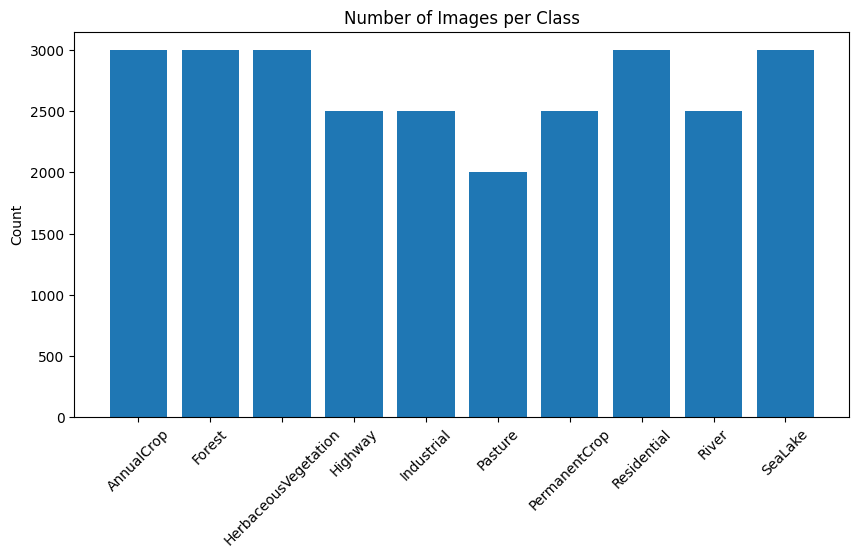

In [4]:
plt.figure(figsize=(10,5))
plt.bar(df_counts["class"], df_counts["num_images"])
plt.xticks(rotation=45)
plt.title("Number of Images per Class")
plt.ylabel("Count")
plt.show()

The dataset is reasonably balanced, although some classes contain fewer images than others. In particular, Pasture has fewer samples than classes such as Forest or SeaLake.

This moderate imbalance should be taken into account when interpreting class-level performance.

## 2.4 Corrupted Image Check

A sample of images from each class was verified to detect possible corrupted files.

No corrupted images were found in the checked sample.

In [5]:
corrupted = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    sample_images = random.sample(images, min(200, len(images)))
    
    for img_path in sample_images:
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupted.append(img_path)

print("Number of corrupted images found:", len(corrupted))

Number of corrupted images found: 0


## Showing sample images

Sample images are displayed below to illustrate the visual variability across classes.

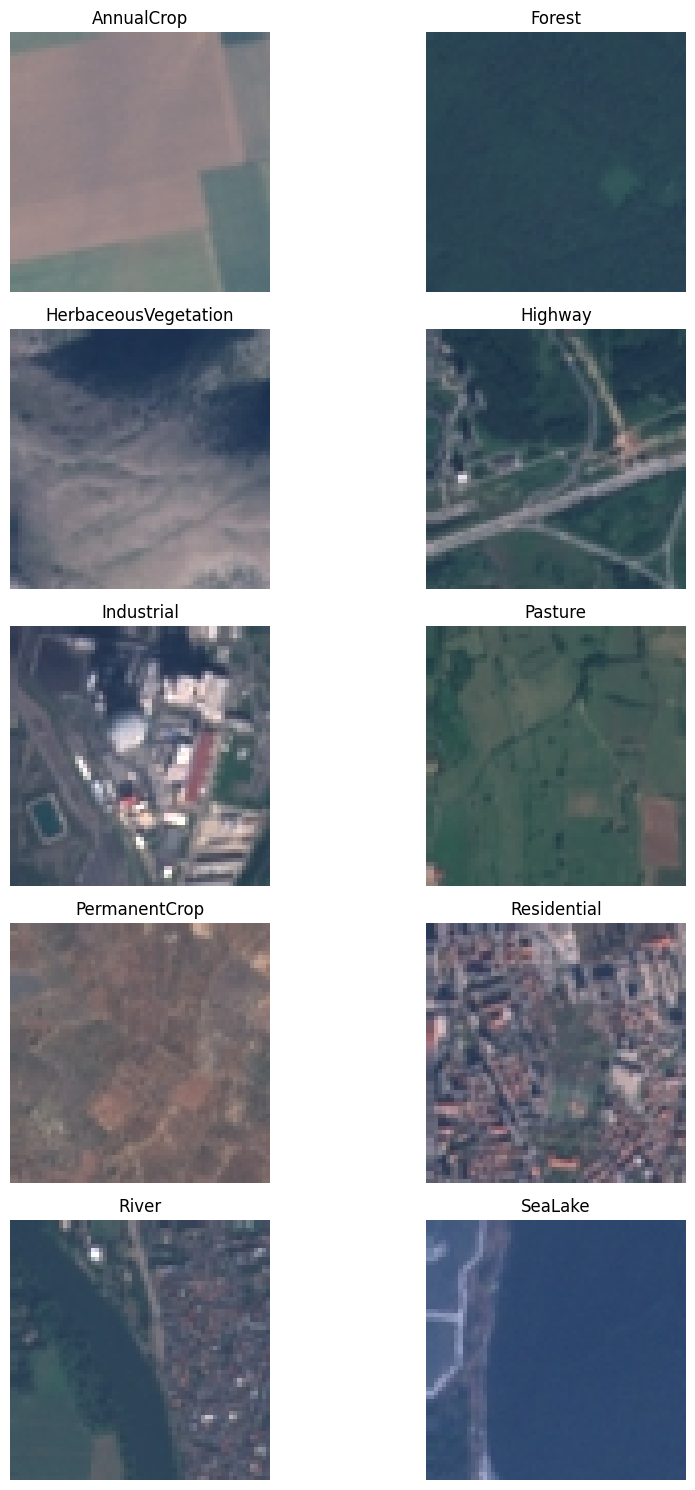

In [6]:
fig, axes = plt.subplots(5, 2, figsize=(10,15))

df_all = pd.read_csv("csv/image_data.csv")  

for ax, cls in zip(axes.flat, classes):
    sample_path = df_all[df_all["label"] == cls]["path"].sample(1).values[0]
    img = plt.imread(sample_path)
    
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2.5 Dataset Indexing

To prepare the dataset for model training, we construct a master DataFrame containing:

- The image file path
- The corresponding class label

This structured representation will allow us to perform a reproducible train/validation/test split while ensuring consistency across models.

In [7]:
all_data = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    for img_path in images:
        all_data.append({
            "path": str(img_path),
            "label": cls
        })

df_all = pd.DataFrame(all_data)

print("Total images indexed:", len(df_all))
df_all.head()

#guardar dataframe por si acaso
df_all.to_csv("csv/image_data.csv", index=False)

Total images indexed: 27000


In [8]:
df_all["label"].value_counts()

label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
Industrial              2500
PermanentCrop           2500
River                   2500
Pasture                 2000
Name: count, dtype: int64

# 3. Experimental Setup

## 3.1 Train / Validation / Test Split

To ensure a fair and reproducible evaluation, the dataset is split into:

- 70% training
- 15% validation
- 15% test

The split is stratified by class so that class proportions remain consistent across subsets.

A fixed random seed is used to guarantee reproducibility.

Before splitting the data, class labels are converted into integer values so they can be used by machine learning models.

In [9]:
#Codificar etiquetas a números
label_encoder = LabelEncoder()

df_all["label_encoded"] = label_encoder.fit_transform(df_all["label"])

num_classes = len(label_encoder.classes_)

print("Number of classes:", num_classes)
print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Number of classes: 10
Class mapping:
0 -> AnnualCrop
1 -> Forest
2 -> HerbaceousVegetation
3 -> Highway
4 -> Industrial
5 -> Pasture
6 -> PermanentCrop
7 -> Residential
8 -> River
9 -> SeaLake


The resulting subsets preserve the original class distribution, which confirms that the stratified split was successful.

In [10]:
SEED = 42

#train vs temp (30% para temp)
train_df, temp_df = train_test_split(
    df_all,
    test_size=0.30,
    stratify=df_all["label_encoded"],
    random_state=SEED
)

# Dividir temp en validation (15%) y test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_encoded"],
    random_state=SEED
)

#verify size of splits
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 18900
Validation size: 4050
Test size: 4050


In [11]:
print("Train distribution:\n", train_df["label"].value_counts(normalize=True))
print("\nValidation distribution:\n", val_df["label"].value_counts(normalize=True))
print("\nTest distribution:\n", test_df["label"].value_counts(normalize=True))

Train distribution:
 label
Residential             0.111111
SeaLake                 0.111111
AnnualCrop              0.111111
Forest                  0.111111
HerbaceousVegetation    0.111111
PermanentCrop           0.092593
Industrial              0.092593
Highway                 0.092593
River                   0.092593
Pasture                 0.074074
Name: proportion, dtype: float64

Validation distribution:
 label
SeaLake                 0.111111
HerbaceousVegetation    0.111111
Forest                  0.111111
AnnualCrop              0.111111
Residential             0.111111
Highway                 0.092593
Industrial              0.092593
PermanentCrop           0.092593
River                   0.092593
Pasture                 0.074074
Name: proportion, dtype: float64

Test distribution:
 label
SeaLake                 0.111111
AnnualCrop              0.111111
Residential             0.111111
Forest                  0.111111
HerbaceousVegetation    0.111111
PermanentCrop         

In [12]:
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

df_splits = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

df_splits.head(),df_splits["split"].value_counts()

(                                   path        label  label_encoded  split
 0   img\Residential\Residential_238.jpg  Residential              7  train
 1          img\SeaLake\SeaLake_1784.jpg      SeaLake              9  train
 2  img\Residential\Residential_2621.jpg  Residential              7  train
 3     img\AnnualCrop\AnnualCrop_361.jpg   AnnualCrop              0  train
 4            img\Forest\Forest_1198.jpg       Forest              1  train,
 split
 train    18900
 val       4050
 test      4050
 Name: count, dtype: int64)

The same data split is used for both Random Forest and CNN models, ensuring a fair comparison between the two approaches.

In [13]:
train_df.to_csv("csv/train_data.csv", index=False)
val_df.to_csv("csv/val_data.csv", index=False) 
test_df.to_csv("csv/test_data.csv", index=False)

df_splits.to_csv("csv/splits_data.csv", index=False)

## 3.2 Evaluation Functions

The following helper functions are defined to evaluate all models consistently using the same metrics and visualisations.

### Confusion Matrix

This function plots both raw and normalised confusion matrices to analyse class-level prediction behaviour.

In [14]:
def plot_confusion_matrix(y_true, y_pred, class_names, normalize=False):
    """
    Plots confusion matrix.
    
    Parameters:
    - y_true: true labels
    - y_pred: predicted labels
    - class_names: list of class names
    - normalize: if True, show percentages instead of raw counts
    """
    
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Model Evaluation

This function reports accuracy, macro-F1 score, the classification report and confusion matrices.

In [15]:
def evaluate_model(y_true, y_pred, class_names, model_name="Model"):
    """
    Computes and prints evaluation metrics.
    Returns dictionary with results.
    """
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    
    print(f"\n===== {model_name} Evaluation =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {f1_macro:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion matrices
    plot_confusion_matrix(y_true, y_pred, class_names, normalize=False)
    plot_confusion_matrix(y_true, y_pred, class_names, normalize=True)
    
    return {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": f1_macro
    }

### Comparative Table

This function creates a summary table to compare the results of different models.

In [16]:
def compare_models(results_list):
    """
    Creates comparison table from evaluation results.
    
    results_list: list of dictionaries returned by evaluate_model()
    """
    
    results_df = pd.DataFrame(results_list)
    results_df = results_df.set_index("model")
    
    print("\n===== Model Comparison =====")
    display(results_df)
    
    return results_df

# 4. Baseline Model: Random Forest

Random Forest is an ensemble learning method that combines many decision trees trained on bootstrapped samples of the data. At each split, only a random subset of features is considered, which increases diversity among trees and improves generalisation.

Using raw pixels directly would give 12,288 input values per 64×64 RGB image, which is too high-dimensional and poorly structured for this type of model. For this reason, images are first transformed into HOG descriptors, which summarise local edge and texture information in a compact numerical representation.

## 4.1 Feature Extraction: HOG Descriptors

In this section, each image is transformed into a HOG feature vector so that it can be used as input for the Random Forest model.

HOG captures local edge directions and texture patterns, which are often informative in land-use classification. This also reduces the input dimensionality substantially, making the problem more suitable for a classical machine learning model.

HOG divides each image into small cells, computes gradient orientations inside each cell, and aggregates them into a compact descriptor.

The following configuration is used:

- `pixels_per_cell = (8, 8)`: defines the local spatial granularity
- `cells_per_block = (2, 2)`: normalises neighbouring cells for better robustness to illumination changes
- `orientations = 9`: uses 9 gradient direction bins
- `channel_axis = -1`: processes the RGB channels jointly

With this setup, each image is represented by 1,764 features.

In [17]:
from skimage.feature import hog
from PIL import Image
import numpy as np
from tqdm import tqdm

def extract_hog_features(df, pixels_per_cell=(8,8), cells_per_block=(2,2), orientations=9):
    """
    Extracts HOG feature vectors for all images in df.
    Returns X: numpy array of shape (n_images, n_features)
    """
    features = []
    for img_path in tqdm(df["path"], desc="Extracting HOG features"):
        img = np.array(Image.open(img_path).convert("RGB"))
        hog_vec = hog(
            img,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            channel_axis=-1
        )
        features.append(hog_vec)
    return np.array(features)

print("Extracting HOG features...")
X_train_hog = extract_hog_features(train_df)
X_val_hog   = extract_hog_features(val_df)
X_test_hog  = extract_hog_features(test_df)

Y_train = train_df["label_encoded"].values
Y_val   = val_df["label_encoded"].values
Y_test  = test_df["label_encoded"].values

print(f"\nHOG feature vector length: {X_train_hog.shape[1]}")
print(f"Train: {X_train_hog.shape} | Val: {X_val_hog.shape} | Test: {X_test_hog.shape}")

Extracting HOG features...


Extracting HOG features: 100%|██████████| 4050/4050 [00:08<00:00, 499.97it/s]


HOG feature vector length: 1764
Train: (18900, 1764) | Val: (4050, 1764) | Test: (4050, 1764)


The resulting feature matrix has shape `(n_images, 1764)` for each split. This confirms that all images have been converted successfully into a fixed-length representation that can be used by Random Forest.

## 4.2 Visualising HOG Features

Before training the model, we visualise several examples of original images together with their HOG representation.

The goal is not to evaluate the model yet, but to verify that HOG captures meaningful structural information such as edges, contours and texture patterns that may help distinguish land-use classes.

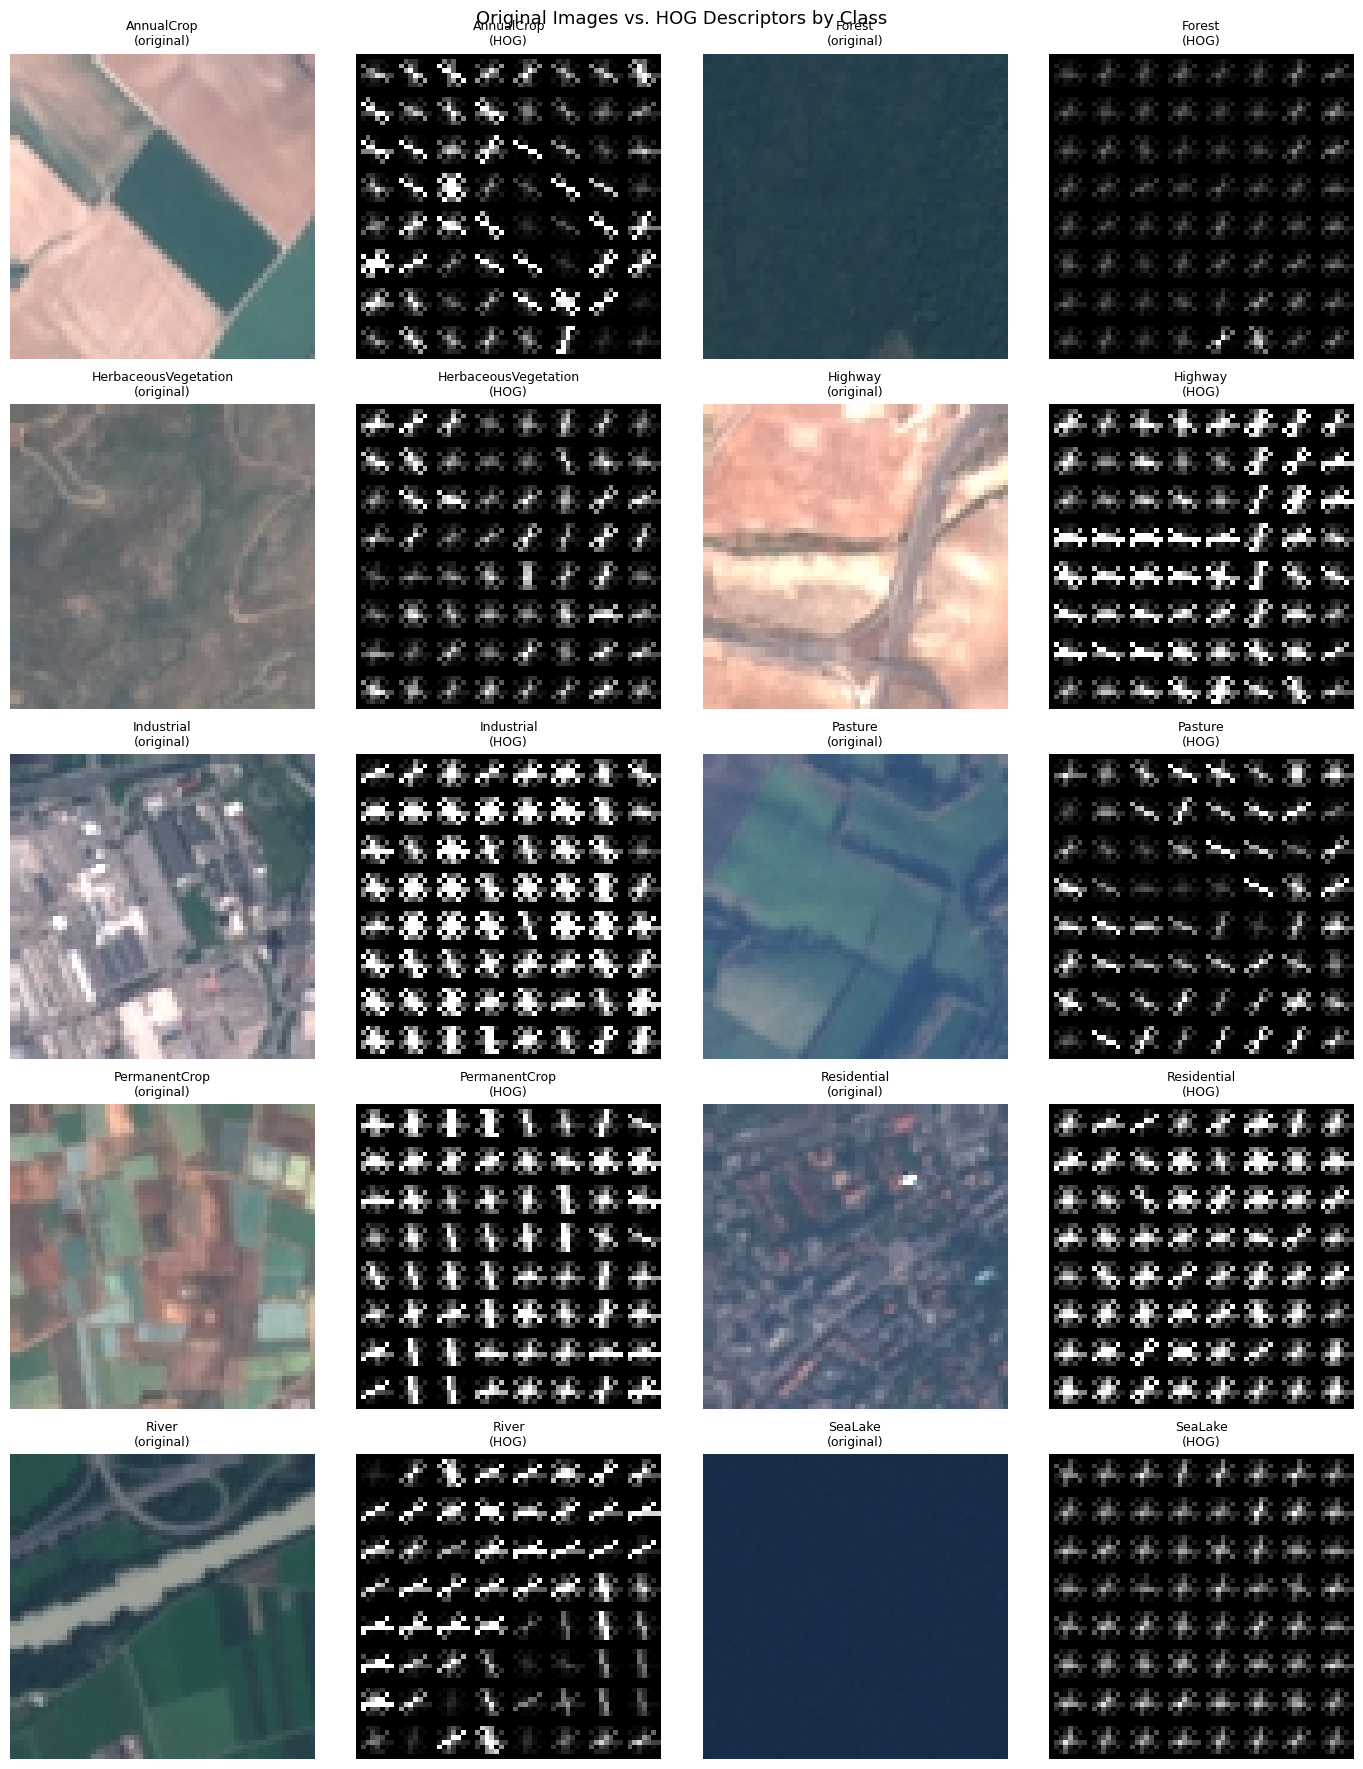

In [18]:
from skimage.feature import hog
from skimage import exposure

fig, axes = plt.subplots(5, 4, figsize=(14, 18))

for idx, cls in enumerate(classes):
    row     = idx // 2
    col_img = (idx % 2) * 2
    col_hog = col_img + 1

    sample_path = train_df[train_df["label"] == cls]["path"].sample(1, random_state=42).values[0]
    img = np.array(Image.open(sample_path).convert("RGB"))

    hog_vec, hog_img = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        channel_axis=-1,
        visualize=True
    )
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[row, col_img].imshow(img)
    axes[row, col_img].set_title(f"{cls}\n(original)", fontsize=9)
    axes[row, col_img].axis("off")

    axes[row, col_hog].imshow(hog_img_rescaled, cmap="gray")
    axes[row, col_hog].set_title(f"{cls}\n(HOG)", fontsize=9)
    axes[row, col_hog].axis("off")

plt.suptitle("Original Images vs. HOG Descriptors by Class", fontsize=13)
plt.tight_layout()
plt.show()

The HOG representations highlight local gradient structure rather than colour information. This is useful for classes with distinctive shapes or textures, but it may be limiting for visually similar categories where colour and broader spatial context also matter.

## 4.3 Baseline Random Forest

A baseline Random Forest is trained to establish a reference level of performance before any hyperparameter tuning.

The baseline uses:
- `n_estimators = 100`, which is large enough to produce stable ensemble behaviour without excessive cost
- `oob_score = True`, so that out-of-bag samples provide an internal estimate of generalisation
- `random_state = 42`, to ensure reproducibility

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train_hog, Y_train)

print(f"OOB Score (baseline):  {rf_baseline.oob_score_:.4f}")

y_pred_baseline = rf_baseline.predict(X_test_hog)
acc_baseline = accuracy_score(Y_test, y_pred_baseline)
print(f"Test Accuracy (baseline): {acc_baseline:.4f}")

OOB Score (baseline):  0.5119
Test Accuracy (baseline): 0.5691


The baseline model achieves an OOB score of 0.5119 and a test accuracy of 0.5691.

This indicates that HOG features contain useful structural information, but the model is still far from solving the task reliably. The gap between easy and difficult classes is expected to be large, especially for categories with similar texture and layout.

## 4.4 Baseline Evaluation

The baseline model is evaluated using accuracy, macro-F1 score, the classification report and confusion matrices.

The results show a moderate overall performance. Some classes such as **SeaLake** and **Forest** are classified well, which suggests that their texture and edge structure are distinctive enough for HOG-based features. In contrast, classes such as **Pasture**, **PermanentCrop** and **HerbaceousVegetation** are much harder to separate, likely because they share similar local patterns and require richer spatial or colour information.


===== RF Baseline Evaluation =====
Accuracy: 0.5691
Macro-F1: 0.5248

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.55      0.73      0.63       450
              Forest       0.68      0.90      0.77       450
HerbaceousVegetation       0.32      0.41      0.36       450
             Highway       0.64      0.57      0.60       375
          Industrial       0.52      0.36      0.42       375
             Pasture       0.35      0.09      0.14       300
       PermanentCrop       0.30      0.18      0.22       375
         Residential       0.54      0.79      0.64       450
               River       0.59      0.45      0.51       375
             SeaLake       0.96      0.92      0.94       450

            accuracy                           0.57      4050
           macro avg       0.54      0.54      0.52      4050
        weighted avg       0.55      0.57      0.55      4050



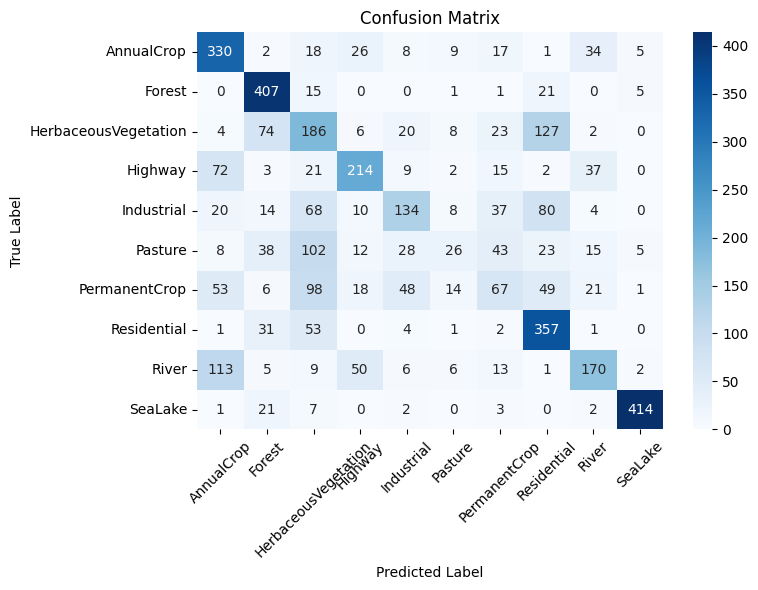

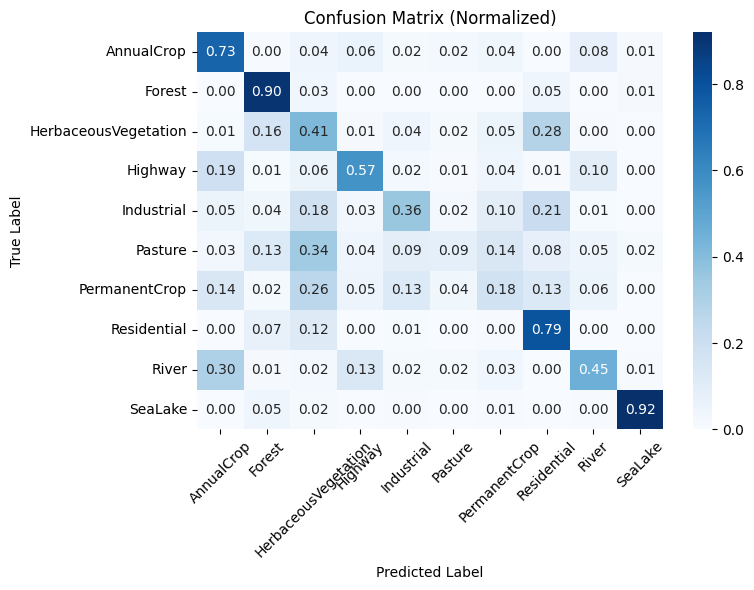

In [20]:
results_baseline = evaluate_model(
    Y_test,
    y_pred_baseline,
    class_names=label_encoder.classes_,
    model_name="RF Baseline"
)

The confusion matrix confirms that most errors occur between visually similar land-use categories, rather than between highly distinct ones. This suggests that the main limitation lies in the representation power of HOG features.

## 4.5 Hyperparameter Tuning

A compact GridSearchCV is used to refine the baseline model while keeping computational cost manageable.

The search space is intentionally small:
- `max_depth`: controls tree complexity
- `min_samples_leaf`: prevents overly specific leaves
- `max_features`: controls how many features are considered at each split

We keep `n_estimators = 100` fixed because the baseline already showed stable behaviour with this ensemble size, and increasing the grid size further would substantially increase runtime with limited expected benefit.

A 3-fold cross-validation is used as a compromise between robustness and efficiency.

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [20, None],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(
        n_estimators=100,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)

rf_grid.fit(X_train_hog, Y_train)

print("\nBest hyperparameters:", rf_grid.best_params_)
print(f"Best CV accuracy:      {rf_grid.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2}
Best CV accuracy:      0.5602


The best cross-validated configuration uses a limited tree depth (`max_depth = 20`) and a slightly more regularised leaf size (`min_samples_leaf = 2`), suggesting that a small amount of regularisation helps reduce overly specific splits.

The best cross-validation accuracy is 0.5602, which is only slightly above the baseline range. This already suggests that hyperparameter tuning may provide only modest gains compared with the effect of the feature representation itself.

## 4.6 Tuned Model Evaluation

The tuned model achieves an OOB score of 0.5207 and a test accuracy of 0.5659.

Although the selected hyperparameters slightly improve the internal validation metrics, the final test performance is marginally lower than the baseline. This suggests that the main limitation is not the Random Forest configuration itself, but the representational capacity of HOG features for this task.

In [22]:
rf_best = rf_grid.best_estimator_

print(f"OOB Score (tuned RF):    {rf_best.oob_score_:.4f}")

y_pred_grid = rf_best.predict(X_test_hog)
acc_grid = accuracy_score(Y_test, y_pred_grid)
print(f"Test Accuracy (tuned RF): {acc_grid:.4f}")

OOB Score (tuned RF):    0.5207
Test Accuracy (tuned RF): 0.5659



===== RF GridSearch Evaluation =====
Accuracy: 0.5659
Macro-F1: 0.5175

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.55      0.73      0.63       450
              Forest       0.68      0.90      0.78       450
HerbaceousVegetation       0.32      0.39      0.35       450
             Highway       0.64      0.59      0.62       375
          Industrial       0.48      0.29      0.36       375
             Pasture       0.26      0.05      0.09       300
       PermanentCrop       0.30      0.19      0.24       375
         Residential       0.53      0.81      0.64       450
               River       0.62      0.48      0.54       375
             SeaLake       0.95      0.93      0.94       450

            accuracy                           0.57      4050
           macro avg       0.53      0.54      0.52      4050
        weighted avg       0.54      0.57      0.54      4050



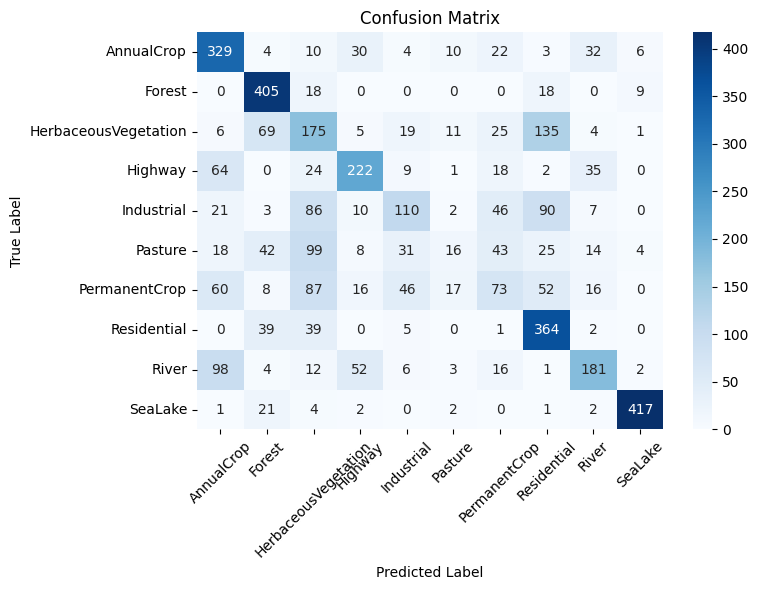

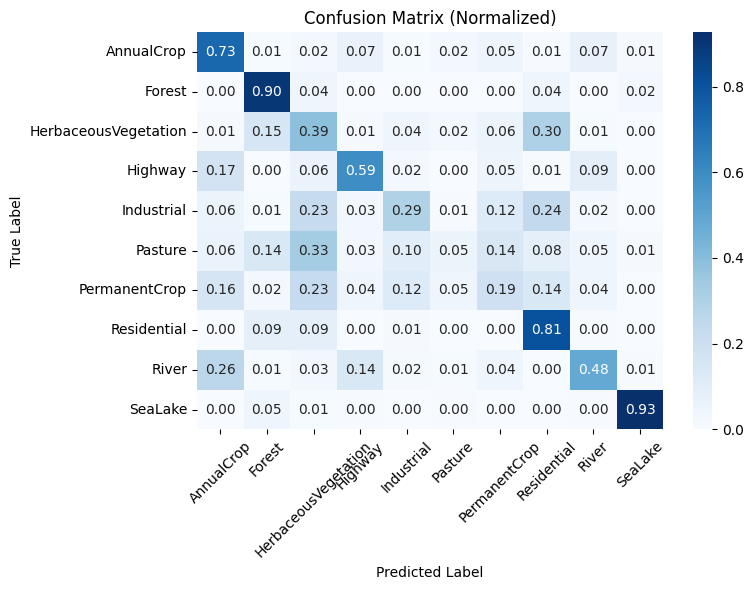

In [23]:
results_grid = evaluate_model(
    Y_test,
    y_pred_grid,
    class_names=label_encoder.classes_,
    model_name="RF GridSearch"
)

In [24]:
print(f"Baseline Accuracy: {acc_baseline:.4f}")
print(f"Tuned Accuracy:    {acc_grid:.4f}")
print(f"Improvement:       {acc_grid - acc_baseline:.4f}")

Baseline Accuracy: 0.5691
Tuned Accuracy:    0.5659
Improvement:       -0.0032


The difference between the baseline and tuned model is very small, and in this case the tuned model performs slightly worse on the test set. Therefore, hyperparameter optimisation does not materially change the conclusions of the Random Forest approach.

We would need more computation power to see improvements.


## 4.7 Feature Importance

Feature importance is analysed on the tuned Random Forest model to identify which HOG components contribute most to the final decisions.

These importances should be interpreted carefully: each feature corresponds to a component of the HOG descriptor, not to a directly meaningful semantic concept. Therefore, the analysis is useful for understanding which local gradient patterns matter most, but not for assigning high-level visual meaning to individual features.

In [25]:
def plot_rf_importances(model, top_n=30):
    """
    Bar chart of top_n most important HOG features.
    """
    importances = model.feature_importances_
    sorted_idx  = np.argsort(importances)[::-1][:top_n]
    sorted_imp  = importances[sorted_idx]

    plt.figure(figsize=(14, 5))
    bars = plt.bar(range(top_n), sorted_imp, color="steelblue", align="center")
    plt.xticks(range(top_n), [f"F{i}" for i in sorted_idx], rotation=90, fontsize=7)
    plt.xlabel("HOG Feature Index")
    plt.ylabel("Importance (Mean Decrease in Impurity)")
    plt.title(f"Top {top_n} Most Important HOG Features")

    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{sorted_imp[i]:.3f}", ha="center", va="bottom", fontsize=6)
    plt.tight_layout()
    plt.show()

In [26]:
def plot_hog_importance_spatial(model, image_shape=(64,64),
                                pixels_per_cell=(8,8), cells_per_block=(2,2), orientations=9):
    """
    Reshapes HOG feature importances back into a spatial heatmap.
    """
    importances   = model.feature_importances_
    n_cells_row   = image_shape[0] // pixels_per_cell[0]
    n_cells_col   = image_shape[1] // pixels_per_cell[1]
    n_blocks_row  = n_cells_row - cells_per_block[0] + 1
    n_blocks_col  = n_cells_col - cells_per_block[1] + 1
    feats_per_block = cells_per_block[0] * cells_per_block[1] * orientations

    spatial_map = np.zeros((n_cells_row, n_cells_col))
    feat_idx = 0

    for br in range(n_blocks_row):
        for bc in range(n_blocks_col):
            block_mean = importances[feat_idx: feat_idx + feats_per_block].mean()
            for cr in range(cells_per_block[0]):
                for cc in range(cells_per_block[1]):
                    spatial_map[br + cr, bc + cc] += block_mean
            feat_idx += feats_per_block

    plt.figure(figsize=(5, 4))
    plt.imshow(spatial_map, cmap="hot", interpolation="nearest")
    plt.colorbar(label="Accumulated Importance")
    plt.title("HOG Feature Importance — Spatial Heatmap")
    plt.xlabel("Image columns (cell grid)")
    plt.ylabel("Image rows (cell grid)")
    plt.tight_layout()
    plt.show()

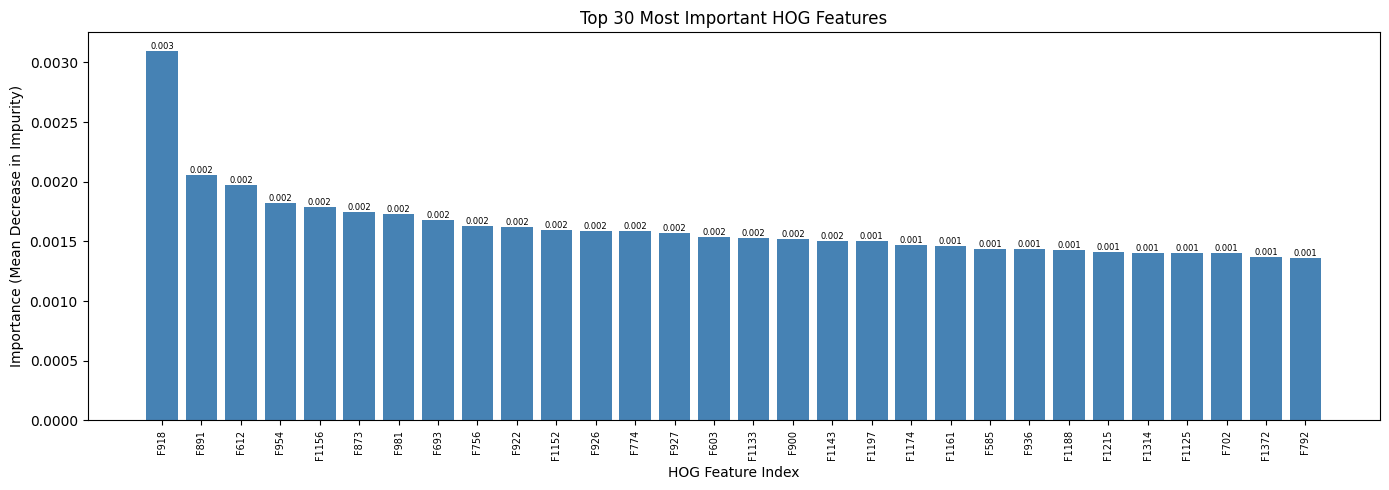

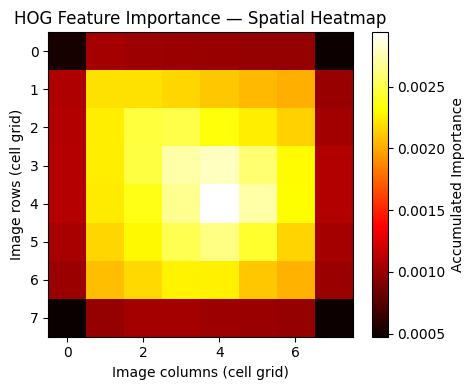

In [27]:
plot_rf_importances(rf_best, top_n=30)
plot_hog_importance_spatial(rf_best)

The bar chart highlights the most influential HOG dimensions, while the spatial heatmap provides a rough indication of where informative gradient patterns tend to appear.

Overall, the model seems to rely on local texture and edge structure rather than on broader scene-level context. This is consistent with the strengths and weaknesses observed in the classification results.

## 4.8 OOB Error vs Number of Trees

This section examines how the out-of-bag error evolves as the number of trees increases.

Random Forests do not usually overfit by simply adding more trees; instead, performance tends to stabilise after a certain point. The goal here is to verify whether the chosen value `n_estimators = 100` is sufficient for this dataset.

c:\Users\alvde\miniconda3\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


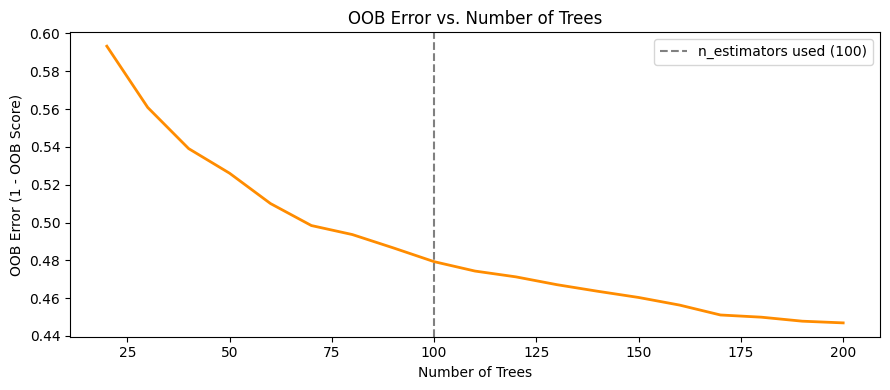

In [57]:
oob_errors = []
n_trees_range = list(range(20, 210, 10))

best_n_estimators = rf_best.n_estimators

for n in n_trees_range:
    rf_oob = RandomForestClassifier(
        n_estimators=n,
        max_depth=rf_grid.best_params_["max_depth"],
        min_samples_leaf=rf_grid.best_params_["min_samples_leaf"],
        max_features=rf_grid.best_params_["max_features"],
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf_oob.fit(X_train_hog, Y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

plt.figure(figsize=(9, 4))
plt.plot(n_trees_range, oob_errors, color="darkorange", linewidth=2)
plt.axvline(x=best_n_estimators, color="gray", linestyle="--",
            label=f"n_estimators used ({best_n_estimators})")
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error (1 - OOB Score)")
plt.title("OOB Error vs. Number of Trees")
plt.legend()
plt.tight_layout()
plt.show()

The OOB error decreases rapidly at first and then stabilises, indicating diminishing returns from adding more trees.

This supports the decision to use 100 trees: the ensemble is already in a stable region, and substantially increasing the number of trees would raise computation time without meaningful performance gains.

## 4.9 Prediction Confidence Analysis

Predicted class probabilities are analysed to assess how confident the model is in its decisions.

This helps distinguish between two different situations:
- the model may be broadly reliable across many images
- or it may only be highly reliable on a small subset of very clear examples

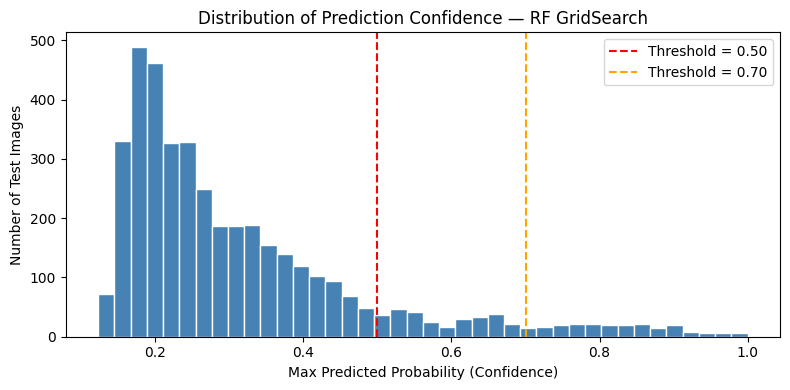

Confidence >= 0.5: 494 images (12.2%)
Confidence >= 0.7: 209 images (5.2%)


In [29]:
y_proba = rf_best.predict_proba(X_test_hog)
max_proba = y_proba.max(axis=1)

plt.figure(figsize=(8, 4))
plt.hist(max_proba, bins=40, color="steelblue", edgecolor="white")
plt.axvline(x=0.5, color="red", linestyle="--", label="Threshold = 0.50")
plt.axvline(x=0.7, color="orange", linestyle="--", label="Threshold = 0.70")
plt.xlabel("Max Predicted Probability (Confidence)")
plt.ylabel("Number of Test Images")
plt.title("Distribution of Prediction Confidence — RF GridSearch")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Confidence >= 0.5: {(max_proba >= 0.5).sum()} images ({(max_proba >= 0.5).mean():.1%})")
print(f"Confidence >= 0.7: {(max_proba >= 0.7).sum()} images ({(max_proba >= 0.7).mean():.1%})")

In [30]:
thresholds = [0.5, 0.6, 0.7, 0.8]

for t in thresholds:
    mask = max_proba >= t
    coverage = mask.mean()

    if mask.sum() > 0:
        acc_t = (y_pred_grid[mask] == Y_test[mask]).mean()
        print(f"Threshold {t:.1f} -> Coverage: {coverage:.2%} | Accuracy: {acc_t:.4f}")
    else:
        print(f"Threshold {t:.1f} -> No predictions above threshold")

Threshold 0.5 -> Coverage: 12.20% | Accuracy: 0.9879
Threshold 0.6 -> Coverage: 8.57% | Accuracy: 1.0000
Threshold 0.7 -> Coverage: 5.16% | Accuracy: 1.0000
Threshold 0.8 -> Coverage: 3.06% | Accuracy: 1.0000


The confidence distribution shows that only a relatively small fraction of test images receive high-confidence predictions. However, when the model is highly confident, its accuracy is extremely high.

This indicates that the Random Forest identifies some very clear cases well, but remains uncertain for a large portion of the dataset. In other words, confidence is informative, but coverage is low.

## 4.10 Per-Class Analysis

Per-class recall is analysed to identify which categories are easier or harder for the Random Forest model.

This is especially important in multiclass image classification, because overall accuracy can hide strong differences between classes.

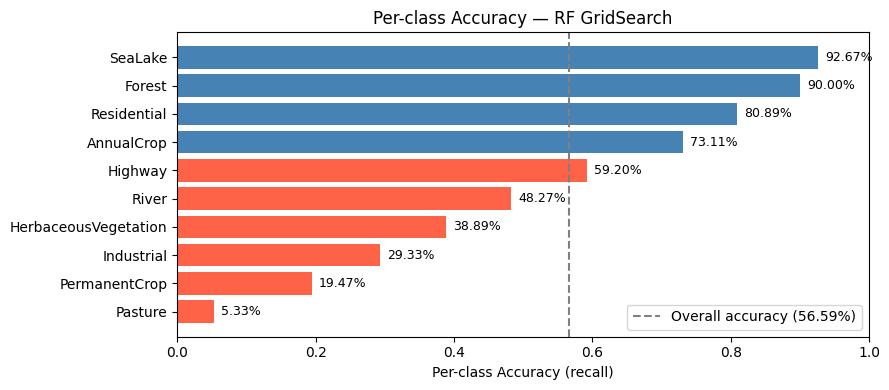


Worst-performing classes:
        Class  Per-class Accuracy
      Pasture            0.053333
PermanentCrop            0.194667
   Industrial            0.293333


In [31]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(Y_test, y_pred_grid, normalize="true")
per_class_acc = cm.diagonal()

class_acc_df = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Per-class Accuracy": per_class_acc
}).sort_values("Per-class Accuracy")

colors = ["tomato" if a < 0.7 else "steelblue" for a in class_acc_df["Per-class Accuracy"]]

plt.figure(figsize=(9, 4))
bars = plt.barh(class_acc_df["Class"], class_acc_df["Per-class Accuracy"], color=colors)
plt.axvline(x=acc_grid, color="gray", linestyle="--", label=f"Overall accuracy ({acc_grid:.2%})")
plt.xlabel("Per-class Accuracy (recall)")
plt.title("Per-class Accuracy — RF GridSearch")
plt.xlim(0, 1)

for bar, val in zip(bars, class_acc_df["Per-class Accuracy"]):
    plt.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val:.2%}", va="center", fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()

print("\nWorst-performing classes:")
print(class_acc_df.head(3).to_string(index=False))

The worst-performing classes are **Pasture**, **PermanentCrop** and **Industrial**.

These categories are likely harder because they share similar local textures with other classes or require broader spatial context that HOG descriptors do not capture well. By contrast, classes with more distinctive visual structure, such as **SeaLake** or **Forest**, are easier for the model to recognise.

This pattern suggests that a CNN may perform better, since it can learn hierarchical spatial representations directly from the images instead of relying only on handcrafted gradient descriptors.

## 4.11 Results Summary

Overall, Random Forest with HOG features provides a useful classical baseline for this problem.

The model captures part of the structural information present in the images and performs well on highly distinctive classes. However, its performance remains limited on visually similar categories, and hyperparameter tuning does not materially improve the final test results. This suggests that the main bottleneck is the feature representation rather than the classifier itself.

In [32]:
rf_summary = {
    "Model": "Random Forest (GridSearch)",
    "Features": f"HOG ({X_train_hog.shape[1]} dims)",
    "n_estimators": rf_best.n_estimators,
    "Best params": rf_grid.best_params_,
    "OOB Score": round(rf_best.oob_score_, 4),
    "Baseline Acc": round(acc_baseline, 4),
    "Tuned Acc": round(acc_grid, 4),
    "Macro-F1": round(results_grid["macro_f1"], 4)
}

print("\n===== Random Forest Summary =====")
for k, v in rf_summary.items():
    print(f"  {k:20s}: {v}")


===== Random Forest Summary =====
  Model               : Random Forest (GridSearch)
  Features            : HOG (1764 dims)
  n_estimators        : 100
  Best params         : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2}
  OOB Score           : 0.5207
  Baseline Acc        : 0.5691
  Tuned Acc           : 0.5659
  Macro-F1            : 0.5175


# 5. Main Model: CNN

Unlike the Random Forest approach, which depends on handcrafted HOG descriptors, the CNN learns feature representations directly from the raw images.

This is especially relevant for satellite image classification, where spatial structure, texture and context are essential. The CNN is therefore expected to overcome the main limitation observed in the Random Forest model: the restricted representational power of handcrafted features.

## 5.1 Data Loading and Verification

The train, validation and test splits created in the preprocessing section are loaded from CSV files.

Using the same split as in the Random Forest pipeline ensures a fair comparison between both modelling approaches.

In [ ]:
train_csv = "csv/train_data.csv"
val_csv   = "csv/val_data.csv"
test_csv  = "csv/test_data.csv"

train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Shapes:")
print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)


Shapes:
train: (18900, 4) val: (4050, 4) test: (4050, 4)


The loaded dataframes contain 18,900 training images, 4,050 validation images and 4,050 test images, matching the predefined split sizes.

## 5.2 Paths and Labels Extraction

The image paths and encoded labels are extracted from the dataframes and converted into NumPy arrays.

These arrays are later used to build the TensorFlow input pipeline.

In [ ]:
# Convertimos a arrays (esto es lo que alimentará tf.data.Dataset)
train_paths  = train_df["path"].astype(str).to_numpy()
train_labels = train_df["label_encoded"].astype(int).to_numpy()

val_paths  = val_df["path"].astype(str).to_numpy()
val_labels = val_df["label_encoded"].astype(int).to_numpy()

test_paths  = test_df["path"].astype(str).to_numpy()
test_labels = test_df["label_encoded"].astype(int).to_numpy()

print("train_paths:", train_paths.shape, "train_labels:", train_labels.shape)
print("val_paths:  ", val_paths.shape,   "val_labels:  ", val_labels.shape)
print("test_paths: ", test_paths.shape,  "test_labels: ", test_labels.shape)

# Sanity check rápido (primeros 3)
for i in range(3):
    print("\nEjemplo", i)
    print("  path :", train_paths[i])
    print("  label:", train_labels[i])

train_paths: (18900,) train_labels: (18900,)
val_paths:   (4050,) val_labels:   (4050,)
test_paths:  (4050,) test_labels:  (4050,)

Ejemplo 0
  path : img\Residential\Residential_238.jpg
  label: 7

Ejemplo 1
  path : img\SeaLake\SeaLake_1784.jpg
  label: 9

Ejemplo 2
  path : img\Residential\Residential_2621.jpg
  label: 7


This step separates the dataset into two basic components required for training: the file location of each image and its numerical class label.


## 5.3 Data Pipeline

The CNN receives images as tensors rather than as handcrafted feature vectors.

Each image is:
- read from disk,
- decoded as RGB,
- resized to a fixed size,
- normalised to the range [0,1].

The `tf.data` pipeline also applies batching and prefetching, which improves training efficiency.

TensorFlow/Keras is used because it provides a simple and robust framework for building image pipelines and CNN models, while also offering efficient training utilities through `tf.data`.

In [36]:
import tensorflow as tf

IMG_SIZE = 64
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

The input size is kept at 64×64 pixels because this is the original resolution of the EuroSAT RGB images.

This avoids unnecessary interpolation and keeps the computational cost low while preserving all available image information.

A batch size of 32 is used as a practical compromise between computational efficiency and memory consumption. It is large enough to provide stable gradient updates while remaining manageable on standard hardware.

In [ ]:
def preprocess_image(path, label):
    # Leer imagen
    image = tf.io.read_file(path)
    
    # Decodificar (forzamos 3 canales RGB)
    image = tf.image.decode_jpeg(image, channels=3)
    
    # Redimensionar a 224x224
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    
    # Normalizar a rango [0,1]
    image = image / 255.0
    
    return image, label

# #3.2 Crear Dataset base

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds   = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds  = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

In [38]:
# #3.3 Aplicar map (preprocesado)

train_ds = train_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
test_ds  = test_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)

In [39]:
# #3.4 Shuffle solo en entrenamiento

train_ds = train_ds.shuffle(buffer_size=len(train_paths))

In [40]:
# #3.5 Batching

train_ds = train_ds.batch(BATCH_SIZE)
val_ds   = val_ds.batch(BATCH_SIZE)
test_ds  = test_ds.batch(BATCH_SIZE)

In [41]:
# #3.6 Prefetch

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

In [42]:
for images, labels in train_ds.take(1):
    print("Shape imágenes:", images.shape)   # (32, 224, 224, 3)
    print("Shape labels:", labels.shape)     # (32,)
    print("Min pixel:", tf.reduce_min(images).numpy())
    print("Max pixel:", tf.reduce_max(images).numpy())
    

Shape imágenes: (32, 64, 64, 3)
Shape labels: (32,)
Min pixel: 0.07450981
Max pixel: 1.0


## 5.4 CNN Architecture

A simple CNN is used as the main deep learning model.

The architecture consists of three convolutional blocks followed by a dense classifier:
- convolutional layers extract local spatial patterns,
- max-pooling progressively reduces spatial resolution,
- deeper layers learn more abstract visual structures,
- the final dense layers map the learned representation to the 10 output classes.

In [43]:
from tensorflow.keras import layers, models

num_classes = 10

model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,498 (1.11 MB)

 Trainable params: 291,498 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

This architecture was intentionally kept simple in order to provide a clear and interpretable baseline deep learning model.

The number of filters increases gradually from 32 to 64, allowing the network to learn more complex patterns at deeper levels while keeping the model computationally affordable.

The model is compiled with the Adam optimiser and sparse categorical crossentropy.

- **Adam** is a standard choice for efficient optimisation in CNN training.
- **Sparse categorical crossentropy** is appropriate because the problem is multiclass and labels are encoded as integers.
- **Softmax** in the final layer converts the outputs into class probabilities.

The architecture uses a `Flatten` layer before the dense classifier. This is simple and effective for a compact network, although more advanced versions could replace it with `GlobalAveragePooling2D` to reduce the number of parameters and improve regularisation.

## 5.5 Training

The model is trained for 10 epochs using the training set, while validation performance is monitored after each epoch.

This allows us to observe both the learning progress and potential signs of overfitting.

In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.5013 - loss: 1.3037 - val_accuracy: 0.6314 - val_loss: 0.9901
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.6796 - loss: 0.8893 - val_accuracy: 0.7225 - val_loss: 0.7593
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.7443 - loss: 0.7114 - val_accuracy: 0.7595 - val_loss: 0.6676
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.7812 - loss: 0.6155 - val_accuracy: 0.7906 - val_loss: 0.5976
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.8075 - loss: 0.5424 - val_accuracy: 0.8138 - val_loss: 0.5271
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.8298 - loss: 0.4850 - val_accuracy: 0.7454 - val_loss: 0.7022
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.8393 - loss: 0.4484 - val_accuracy: 0.8138 - val_loss: 0.5229
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.8644 - loss: 0.3867 - 

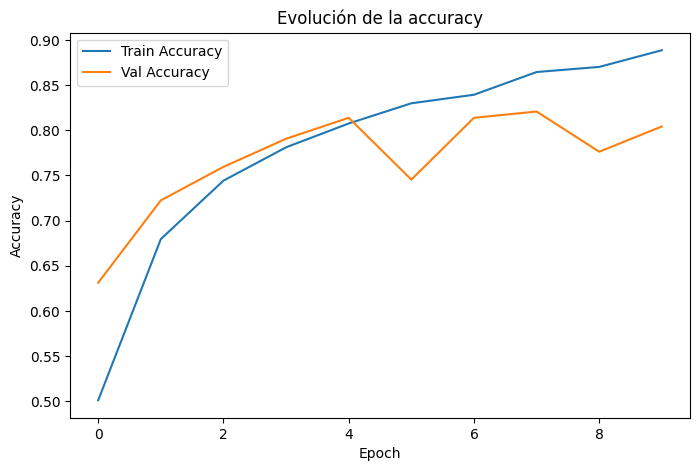

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Evolución de la accuracy')
plt.legend()
plt.show()

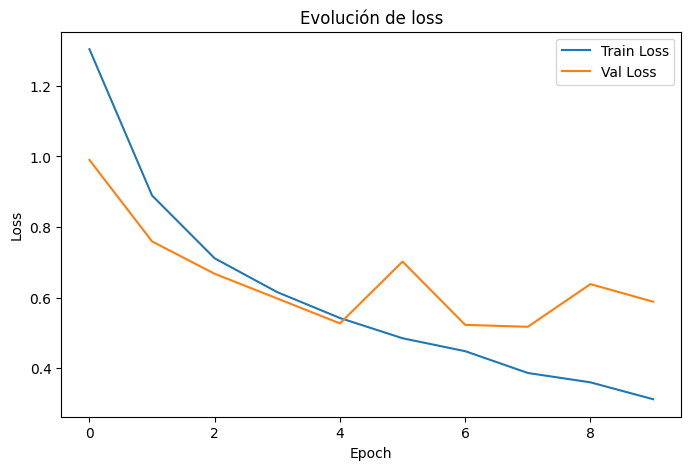

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolución de loss')
plt.legend()
plt.show()

The training curves show a clear learning process during the first epochs, with both training accuracy increasing and validation loss decreasing.

However, after approximately epoch 5, validation performance becomes less stable while training performance continues to improve. This suggests that the model starts to overfit the training set, even though its overall validation accuracy remains strong.

This behaviour suggests that a future improvement would be to use `EarlyStopping`, so that training stops automatically when validation loss no longer improves.

## 5.6 Test Evaluation

The final model is evaluated on the test set using the same general framework as the Random Forest model.

This provides a direct comparison between handcrafted-feature learning and end-to-end image learning.

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8099 - loss: 0.5443
Test Loss: 0.5443
Test Accuracy: 0.8099


The CNN achieves a test accuracy of approximately 0.81, which is substantially higher than the Random Forest results obtained in Section 4.

This confirms that learning features directly from the raw images is much more effective for this task than relying on fixed HOG descriptors.

## 5.7 Predictions and Label Recovery

Class probabilities are generated for each test image, and the predicted label is obtained by selecting the class with the highest probability.

The original class names are also recovered in order to interpret the confusion matrix and classification report more easily.

In [ ]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Shape probabilidades:", y_pred_probs.shape)
print("Shape predicciones:", y_pred.shape)
print("Primeras 10 predicciones:", y_pred[:10])

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
Shape probabilidades: (4050, 10)
Shape predicciones: (4050,)
Primeras 10 predicciones: [6 9 0 4 5 3 0 9 8 2]


In [ ]:
y_true = np.concatenate([labels.numpy() for images, labels in test_ds])

print("Shape labels reales:", y_true.shape)
print("Primeros 10 labels reales:", y_true[:10])

Shape labels reales: (4050,)
Primeros 10 labels reales: [6 9 0 4 3 3 0 9 8 7]


In [ ]:
class_names = (
    pd.concat([train_df, val_df, test_df])[["label_encoded", "label"]]
    .drop_duplicates()
    .sort_values("label_encoded")["label"]
    .tolist()
)

print(class_names)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 5.8 Detailed Performance Analysis

The confusion matrix and classification report are used to analyse the model beyond overall accuracy.

This makes it possible to identify which classes are learned well and which categories remain more difficult.


===== CNN Evaluation =====
Accuracy: 0.8099
Macro-F1: 0.8039

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.83      0.84      0.83       450
              Forest       0.91      0.90      0.91       450
HerbaceousVegetation       0.88      0.62      0.73       450
             Highway       0.81      0.51      0.63       375
          Industrial       0.91      0.91      0.91       375
             Pasture       0.72      0.80      0.76       300
       PermanentCrop       0.55      0.88      0.68       375
         Residential       0.93      0.90      0.91       450
               River       0.70      0.79      0.74       375
             SeaLake       0.97      0.91      0.94       450

            accuracy                           0.81      4050
           macro avg       0.82      0.81      0.80      4050
        weighted avg       0.83      0.81      0.81      4050



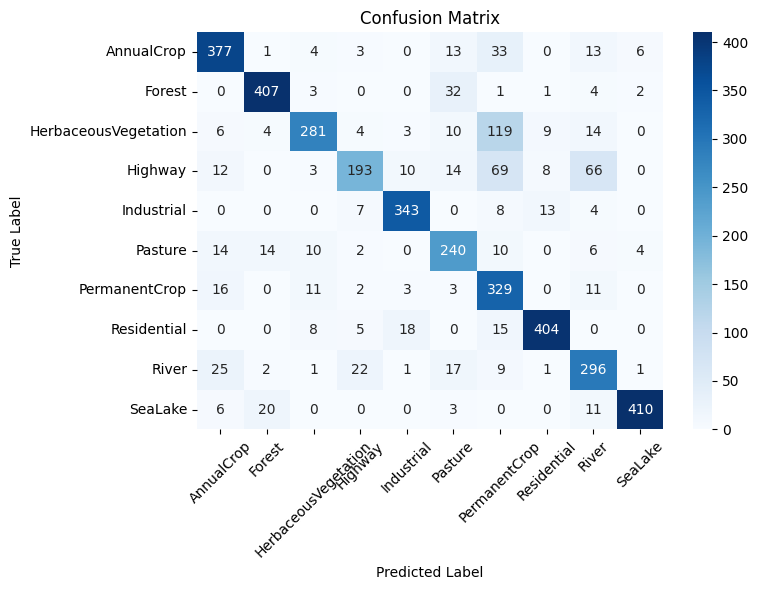

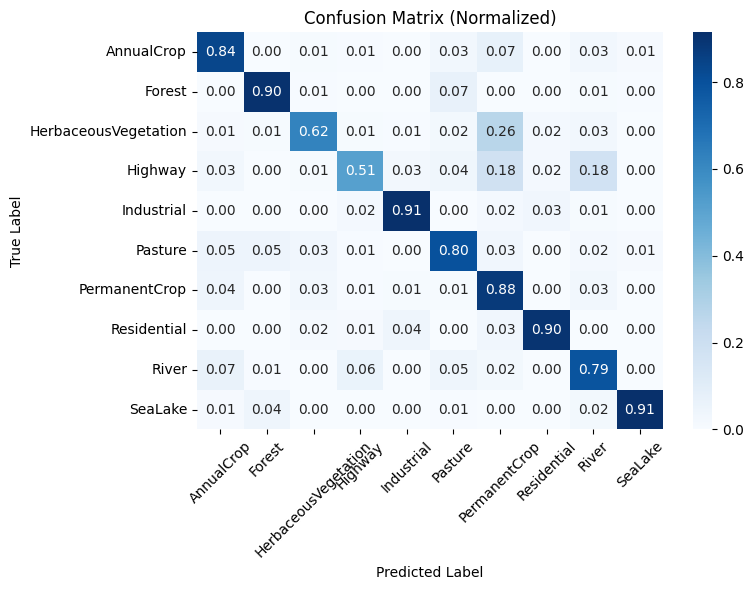

In [64]:
results_cnn = evaluate_model(
    y_true,
    y_pred,
    class_names=class_names,
    model_name="CNN"
)

The CNN shows strong performance across most classes, with particularly high scores for **Residential**, **SeaLake**, **Industrial** and **Forest**.

Compared with the Random Forest model, the CNN reduces confusion in several classes that were previously difficult, which indicates that it is capturing richer spatial and contextual patterns from the images.

Some classes, such as **Highway**, **PermanentCrop** and **River**, remain more challenging. This suggests that even with a CNN, certain categories still present visual overlap or ambiguous structures.

## 5.9 CNN Conclusions

The CNN clearly outperforms the Random Forest baseline, demonstrating the advantage of learning image representations directly from data.

While the Random Forest model depends on handcrafted edge-based descriptors, the CNN captures hierarchical spatial information that is crucial for satellite image classification.

Although the model is relatively simple and shows some signs of overfitting, it already provides a substantial performance improvement over the classical approach.

# 6. Model Comparison and Future Improvements

## 6.1 Comparison Framework

At this point, both modelling approaches have been fully evaluated:

- a **Random Forest** classifier trained on **HOG descriptors**
- a **Convolutional Neural Network (CNN)** trained directly on the raw images

Since both models use the same train/validation/test split, their results can be compared fairly.

To keep the comparison consistent, the final metrics are computed from the predicted labels on the test set.

In [67]:
comparison_df = compare_models([
    results_baseline,
    results_grid,
    results_cnn
])


===== Model Comparison =====


,accuracy,macro_f1
model,,
RF Baseline,0.569136,0.524809
RF GridSearch,0.565926,0.517484
CNN,0.809877,0.803882


## 6.2 Quantitative Comparison

The table above summarises the main test metrics for both models.

The Random Forest reaches a moderate performance, while the CNN achieves a clearly higher accuracy and macro F1-score. This indicates that learning features directly from the images is much more effective than relying on handcrafted HOG descriptors for this task.

<Figure size 800x400 with 0 Axes>

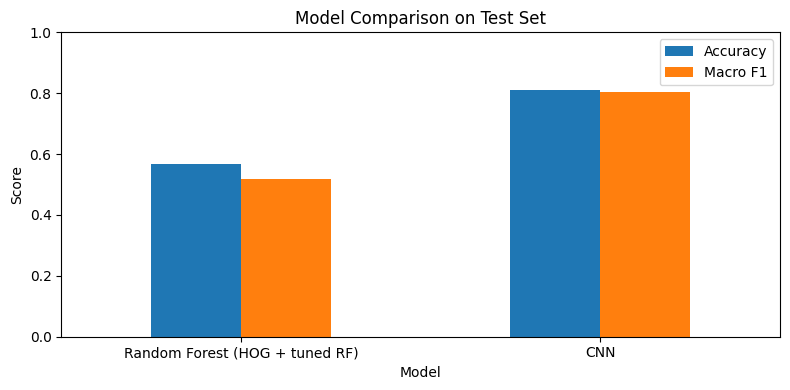

In [60]:
plt.figure(figsize=(8, 4))
comparison_plot = comparison_df.set_index("Model")
comparison_plot.plot(kind="bar", figsize=(8, 4), rot=0)
plt.title("Model Comparison on Test Set")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 6.3 Interpretation of the Comparison

The Random Forest model provides a useful classical baseline, showing that HOG features do capture part of the visual structure of the satellite images.

However, its performance is limited by the feature representation itself:

- HOG focuses mainly on local edge and gradient information
- it does not capture broader spatial context
- it is less effective when classes have similar local textures

This is reflected in the Random Forest results, where classes such as **Pasture**, **PermanentCrop** and **Industrial** remain difficult.

In contrast, the CNN learns its feature representation directly from the raw images.

This allows the model to:
- combine local and global spatial information
- learn hierarchical visual patterns
- adapt the learned features specifically to the land-use classification task

As a result, the CNN performs substantially better, especially on the classes that were problematic for the Random Forest model.

## 6.4 Per-Class Perspective

The difference between both models is not only visible in the overall accuracy, but also at the class level.

The Random Forest performs reasonably well on highly distinctive categories such as **SeaLake** and **Forest**, but fails on more ambiguous categories.

The CNN, on the other hand, improves performance across almost all classes and greatly reduces the gap between easy and difficult categories. Although some classes such as **Highway**, **PermanentCrop** and **River** are still more challenging, the CNN handles them much better overall.

## 6.5 Final Model Choice

Based on the results obtained, the **CNN is the preferred model** for this problem.

The Random Forest remains valuable as:
- a classical baseline,
- a simpler and more interpretable model,
- a reference point for understanding the benefit of deep learning.

However, for predictive performance, the CNN is clearly superior and is therefore the most appropriate final model for satellite image classification in this project.

## 6.6 Main Conclusions

This project highlights the importance of feature representation in image classification.

The Random Forest model shows that a traditional machine learning approach can achieve reasonable results when combined with handcrafted descriptors such as HOG. Nevertheless, its performance is fundamentally constrained by the information contained in those fixed features.

The CNN overcomes this limitation by learning representations directly from the data, leading to a much stronger overall performance and better class-level behaviour.

Therefore, the comparison between both approaches supports a clear conclusion: for this satellite image classification task, **representation learning is more effective than handcrafted feature engineering**.

## 6.7 Future Improvements

Although the CNN already performs much better than the Random Forest baseline, several improvements could be explored in future work.

### 1. Early Stopping
The training curves suggest that the model begins to overfit after several epochs. Using `EarlyStopping` would allow training to stop automatically when validation loss no longer improves.

### 2. Regularisation
Adding techniques such as **Dropout** or **L2 regularisation** could improve generalisation and reduce overfitting.

### 3. Data Augmentation
Applying transformations such as random flips, rotations or zoom could expose the CNN to more variability and make it more robust.

### 4. Improved CNN Architectures
The CNN used here is intentionally simple. More advanced architectures, or transfer learning with pre-trained models, could provide additional gains.

### 5. Hyperparameter Optimisation
Further tuning of the CNN could be explored, including:
- number of filters,
- depth of the network,
- learning rate,
- batch size,
- number of epochs.

### 6. Higher-Resolution Inputs
If computational resources allow it, using larger image sizes could provide more spatial detail and potentially improve discrimination between visually similar classes.